In [19]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [20]:
# Load the dataset
file_path = "Allianz_Dataset.xlsx"  
data = pd.read_excel(file_path)

In [21]:
# Display the first few rows of the dataset
print("Dataset Overview:")
print(data.head())

Dataset Overview:
  Broker_account_number     Contract_number Customer_segment Line_of_business  \
0    DJEA04015816746062  DJUI09715331435925          Midcorp     I - Property   
1    DJEA04015816746062  GJZP42914011343072          Midcorp     I - Property   
2    DJEA04015816746062  NXLM98303446560119          Midcorp     I - Property   
3    DJEA04015816746062  AITL42127947858417          Midcorp     I - Property   
4    UTAY89397600598587  IBPJ05282371448674          Midcorp     D - Property   

     Product_type  Annual_premium Payment_frequency  Customer_ID Customer_age  \
0  I05 - BUILDING         2632.45          Annually    8643674.0       No age   
1  I05 - BUILDING         4996.78          Annually    8338883.0       No age   
2  I05 - BUILDING         1734.62          Annually    8338892.0       No age   
3  I05 - BUILDING         2460.68          Annually    8338893.0       No age   
4  D01 - RISQ IND         7731.46          Annually    3301814.0       No age   

  Custom

In [23]:
# Check for missing values
print("\nMissing Values in Dataset:")
print(data.isnull().sum())


Missing Values in Dataset:
Broker_account_number    0
Contract_number          0
Customer_segment         0
Line_of_business         0
Product_type             0
Annual_premium           0
Payment_frequency        0
Customer_ID              0
Customer_age             0
Customer_type            0
Customer_region          0
Customer_province        0
Broker_region            0
Broker_province          0
Is_direct_debit          0
Broker_cor               0
Customer_urbanization    0
Broker_urbanization      0
dtype: int64


In [24]:
# Preprocess the dataset 
data = data.dropna()  # Drop rows with missing values for simplicity
print(f"\nShape of the dataset after dropping missing values: {data.shape}")



Shape of the dataset after dropping missing values: (452220, 18)


In [25]:
# Define features (X) and target (y)
X = data.drop(columns=["Is_direct_debit"])  
y = data["Is_direct_debit"]

In [26]:
# Convert categorical features to numeric
from sklearn.preprocessing import LabelEncoder

# Identify non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns

# Apply Label Encoding to non-numeric columns
label_encoders = {}
for column in non_numeric_columns:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])

# Check data types after encoding
print("\nData types after encoding:")
print(X.dtypes)



Data types after encoding:
Broker_account_number      int64
Contract_number            int64
Customer_segment           int64
Line_of_business           int64
Product_type               int64
Annual_premium           float64
Payment_frequency          int64
Customer_ID              float64
Customer_age               int64
Customer_type              int64
Customer_region            int64
Customer_province          int64
Broker_region              int64
Broker_province            int64
Broker_cor               float64
Customer_urbanization      int64
Broker_urbanization        int64
dtype: object


In [27]:
# Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [28]:
# Initialize the RandomForestClassifier
model = RandomForestClassifier(random_state=42)

In [29]:
# Train the model
print("\nTraining the model...")
model.fit(X_train, y_train)



Training the model...


RandomForestClassifier(random_state=42)

In [30]:

# Predict on validation set
y_pred = model.predict(X_val)

In [31]:
# Evaluate the model
accuracy = accuracy_score(y_val, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Accuracy: 98.54%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99    107155
         1.0       1.00      0.93      0.96     28511

    accuracy                           0.99    135666
   macro avg       0.99      0.97      0.98    135666
weighted avg       0.99      0.99      0.99    135666



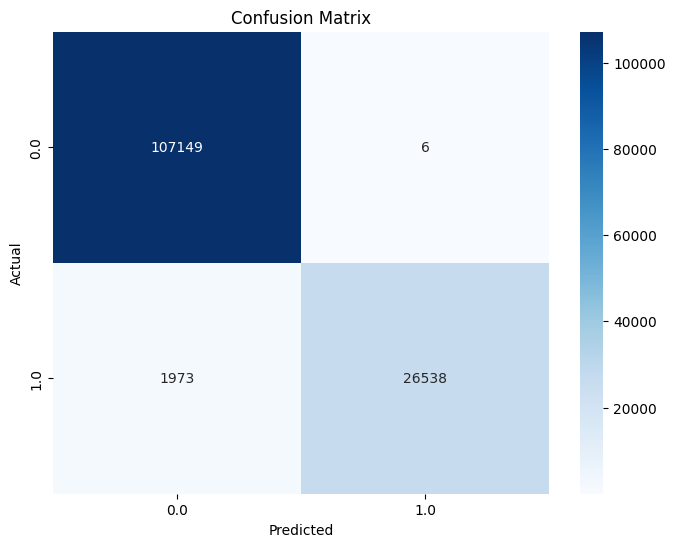

In [32]:
# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

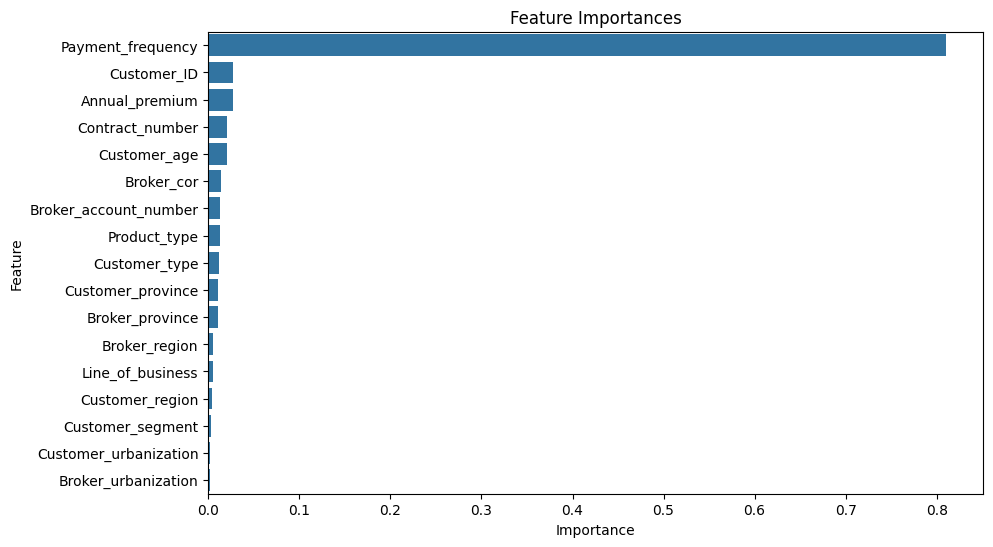

In [33]:
# Feature importance visualization
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importances)
plt.title("Feature Importances")
plt.show()